## Automated Extraction of J-V  Data from Perovskite Solar Cell Research Articles Using ChatGPT Vision Language Models

This study presents an automated pipeline for extracting J-V curve data directly from photovoltaic research articles in PDF format. The pipeline employs 
a cost-efficient three-stage approach: GPT-5.4-mini extracts key performance parameters (PCE, Voc, Jsc, FF) from the abstract, GPT-5.4-mini identifies 
pages containing J-V curve figures, and GPT-5.5 digitizes the actual J-V curve data from the identified figures. The pipeline was validated against a
high-efficiency flexible perovskite/silicon tandem solar cell article published in Nature (PCE=33.6%, Voc=2.015V), demonstrating accurate extraction of
both numerical J-V data points and device parameters directly from published figures without manual digitization.

In [1]:
from pdf2image import convert_from_path
from pathlib import Path
import os

In [2]:
# Poppler path from conda installation
POPPLER_PATH = r"C:\Users\bapon\anaconda3\Library\bin"

# Convert PDF to images
pages = convert_from_path(
    "papers/article.pdf",
    dpi=200,
    output_folder="papers/pages",
    fmt="png",
    paths_only=True,
    poppler_path=POPPLER_PATH
)

print(f"✅ Total pages converted: {len(pages)}")

✅ Total pages converted: 13


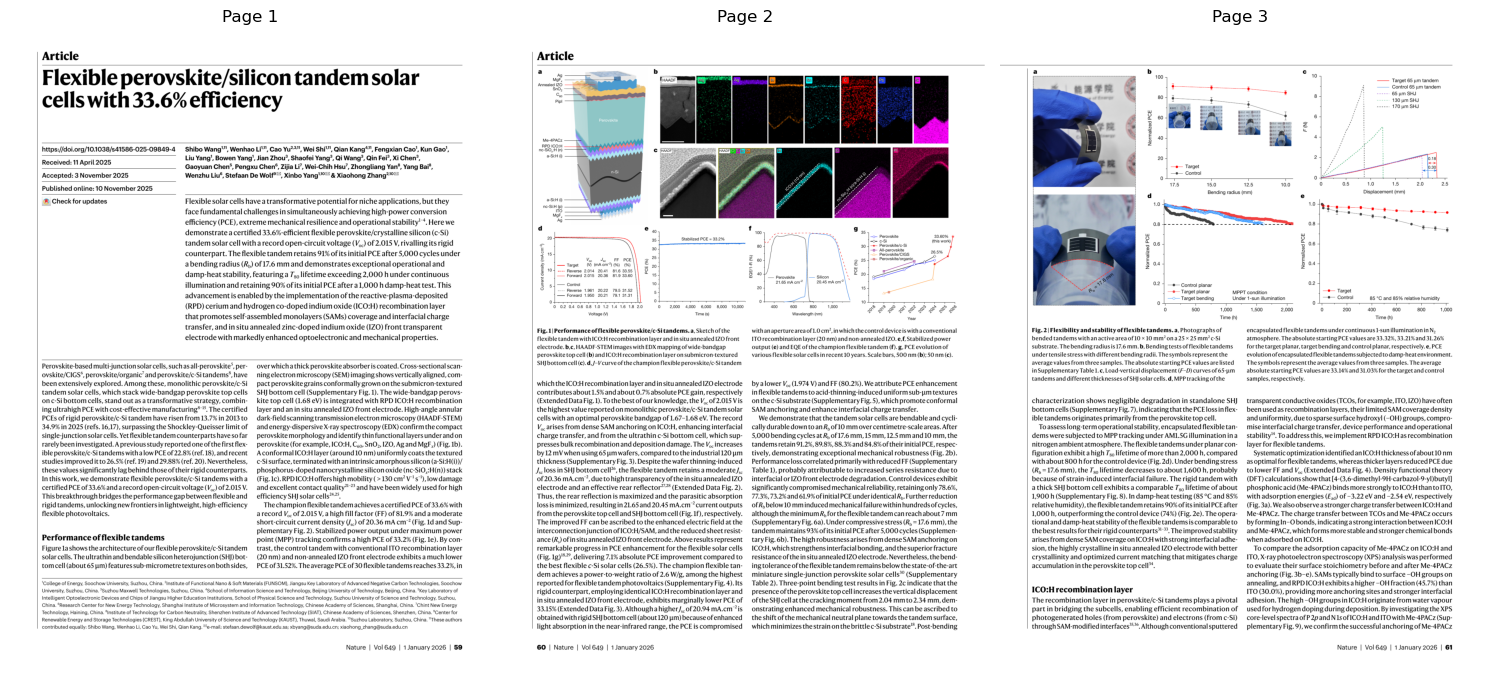

In [3]:
from PIL import Image
import matplotlib.pyplot as plt

# Show first 3 pages as preview
fig, axes = plt.subplots(1, 3, figsize=(15, 10))

for i in range(3):
    img = Image.open(pages[i])
    axes[i].imshow(img)
    axes[i].set_title(f"Page {i+1}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [4]:
import os
import json
import base64
import re
from pathlib import Path
from dotenv import load_dotenv
from openai import OpenAI
from pdf2image import convert_from_path

# Load API keys
load_dotenv()
# Create OpenAI client
client_openai = OpenAI(api_key=os.environ.get("OPENAI_API_KEY"))
print("OpenAI key:", os.environ.get("OPENAI_API_KEY")[:20], "...")

OpenAI key: sk-proj-uPLeKN9HFf3z ...


In [10]:
# Load and encode page 1 (abstract is usually on page 1)
# Converting image bytes → text string
with open(pages[0], "rb") as f:
    page1_base64 = base64.b64encode(f.read()).decode("utf-8")

# Send to GPT-5.4-mini
response_abstract = client_openai.chat.completions.create(
    model="gpt-5.4-mini",
    max_completion_tokens=4000,
    response_format={"type": "json_object"},
    messages=[
        {
            "role": "user",
            "content": [
                {
                    "type": "image_url",
                    "image_url": {
                        "url": f"data:image/png;base64,{page1_base64}",
                        "detail": "high"
                    }
                },
                {
                    "type": "text",
                    "text": """This is page 1 of a perovskite solar cell research article.
Please extract all key parameters mentioned in the abstract.

Extract the following if mentioned:
- PCE (Power Conversion Efficiency) in %
- Voc (Open Circuit Voltage) in V
- Jsc (Short Circuit Current Density) in mA/cm²
- FF (Fill Factor) in %
- Device type (single junction, tandem etc.)
- Material composition
- Stability information
- Any other important performance metrics(Do not repeat same parameters)

Return ONLY this JSON:
{
    "PCE": null,
    "Voc": null,
    "Jsc": null,
    "FF": null,
    "device_type": null,
    "material": null,
    "stability": null,
    "other_parameters": {}
}
Use null if parameter is not mentioned."""
                }
            ]
        }
    ]
)

In [11]:
# Parse response
abstract_data = json.loads(response_abstract.choices[0].message.content)

# Print in a clean formatted way
print("ABSTRACT PARAMETERS EXTRACTED")

print("\n KEY PERFORMANCE PARAMETERS")
print(f"  PCE:         {abstract_data['PCE']} %")
print(f"  Voc:         {abstract_data['Voc']} V")
print(f"  Jsc:         {abstract_data['Jsc'] or 'Not reported'} mA/cm²")
print(f"  FF:          {abstract_data['FF'] or 'Not reported'} %")

print("\n DEVICE INFORMATION")
print(f"  Device type: {abstract_data['device_type']}")
print(f"  Material:    {abstract_data['material']}")

print("\n STABILITY")
print(f"  {abstract_data['stability']}")

print("\n OTHER PARAMETERS")
for key, value in abstract_data['other_parameters'].items():
    clean_key = key.replace("_", " ").title()
    print(f"  {clean_key}: {value}")


ABSTRACT PARAMETERS EXTRACTED

 KEY PERFORMANCE PARAMETERS
  PCE:         33.6% %
  Voc:         2.015 V V
  Jsc:         Not reported mA/cm²
  FF:          Not reported %

 DEVICE INFORMATION
  Device type: flexible perovskite/crystalline silicon (c-Si) tandem solar cell
  Material:    Perovskite/c-Si tandem; RPD cerium and hydrogen co-doped indium oxide (ICO:H) recombination layer; in situ annealed zinc-doped indium oxide (IZO) front transparent electrode; self-assembled monolayers (SAMs)

 STABILITY
  Retains 91% of initial PCE after 5,000 bending cycles at a bending radius of 17.6 mm; T80 lifetime exceeds 2,000 h under continuous illumination; retains 90% of initial PCE after 1,000 h damp-heat test

 OTHER PARAMETERS
  Fill Factor: 81.9%
  Short Circuit Current Density: 20.36 mA/cm²
  Power Output Mpp: 33.2%
  Pce Control Device: 31.52%
  Pce Average Over 30 Flexible Tandems: 33.2%
  Bending Radius: 17.6 mm
  T80: >2,000 h


In [15]:
# Scan all pages to find J-V curve figures
jv_pages = []

for i, page_path in enumerate(pages):
    print(f"Scanning page {i+1}/{len(pages)}...", end=" ")
    
    # Encode page
    with open(page_path, "rb") as f:
        page_base64 = base64.b64encode(f.read()).decode("utf-8")
    
    # Ask GPT-5.4-mini if page contains J-V curve
    response_scan = client_openai.chat.completions.create(
        model="gpt-5.4-mini",
        max_completion_tokens=2000,
        response_format={"type": "json_object"},
        messages=[
            {
                "role": "user",
                "content": [
                    {
                        "type": "image_url",
                        "image_url": {
                            "url": f"data:image/png;base64,{page_base64}",
                            "detail": "high"
                        }
                    },
                    {
                        "type": "text",
                        "text": """You are an expert in photovoltaic research with deep knowledge of solar cell characterization. Look at this page from
a solar cell research paper.Does this page contain a J-V curve (current density vs voltage plot)?

A J-V curve has:
- X axis: Voltage (V)
- Y axis: Current Density (mA/cm²)
- A characteristic S-shaped or knee curve

IMPORTANT RULES:
- IGNORE any J-V curves mentioned only in text or references
- IGNORE reference lists, bibliography, or citations
- IGNORE figures from other cited papers
- IGNORE supplementary figure captions without actual figures
- ONLY detect J-V curves that are clearly plotted as actual figures on this page
- The figure must have visible axes, data points or curves

Return ONLY this JSON:
{
    "has_jv_curve": true or false,
    "confidence": "high/medium/low",
    "page_type": "main text/extended data/supplementary/references/other",
    "description": "brief description of what you see"
}"""
                    }
                ]
            }
        ]
    )
    
    # Parse result
    result = json.loads(response_scan.choices[0].message.content)
    
    if result["has_jv_curve"] and result["page_type"] == "main text":
        jv_pages.append({
            "page_number": i + 1,
            "page_path": page_path,
            "confidence": result["confidence"],
            "description": result["description"]
        })
        print(f"✅ J-V curve found! ({result['confidence']} confidence)")
    else:
        print(f"❌ No J-V curve")

# Summary
print(f"Total pages scanned: {len(pages)}")
print(f"Pages with J-V curves: {len(jv_pages)}")
print(f"\nJ-V pages found:")
for p in jv_pages:
    print(f"  Page {p['page_number']}: {p['description']}")

Scanning page 1/13... ❌ No J-V curve
✅ J-V curve found! (high confidence)
❌ No J-V curve3/13... 
❌ No J-V curve4/13... 
❌ No J-V curve5/13... 
❌ No J-V curve6/13... 
❌ No J-V curve7/13... 
❌ No J-V curve8/13... 
❌ No J-V curve9/13... 
❌ No J-V curve10/13... 
❌ No J-V curve11/13... 
❌ No J-V curve12/13... 
❌ No J-V curve13/13... 
Total pages scanned: 13
Pages with J-V curves: 1

J-V pages found:
  Page 2: The page contains a J-V plot in panel d, with voltage on the x-axis and current density on the y-axis, showing forward/reverse curves and a typical solar-cell knee shape.


In [16]:
# Save J-V page locations
with open("outputs/jv_pages_found.json", "w") as f:
    json.dump(jv_pages, f, indent=2)

print("J-V pages saved")

J-V pages saved


In [31]:
# Take only first J-V page
jv_page = jv_pages[0]  # Page 2
page_num = jv_page["page_number"]
page_path = jv_page["page_path"]

print(f"Extracting J-V data from Page {page_num}...")

# Encode page
with open(page_path, "rb") as f:
    page_base64 = base64.b64encode(f.read()).decode("utf-8")

# Send to GPT-5.5
response_jv = client_openai.chat.completions.create(
    model="gpt-5.5",
    max_completion_tokens=10000,
    response_format={"type": "json_object"},
    messages=[
        {
            "role": "user",
            "content": [
                {
                    "type": "image_url",
                    "image_url": {
                        "url": f"data:image/png;base64,{page_base64}",
                        "detail": "high"
                    }
                },
                {
                    "type": "text",
                    "text": """I am a photovoltaic solar cell researcher. This is a page from my research article containing multiple figures.
I need to extract J-V curve data from this page.
You are an expert in photovoltaic J-V curve analysis and scientific plot digitization.

IMPORTANT:
- Perform the best possible visual digitization from the image.
- Do not suggest WebPlotDigitizer, Engauge Digitizer, or any other external tools.
- The extracted values must be based only on the visible experimental curve.
- Return JSON only. No explanation, no markdown, no extra text.

STEP 1 — IDENTIFY THE J-V PLOT:
- This page may contain multiple panels (a, b, c, d etc.)
- Find the panel that shows a J-V curve specifically
- J-V curve has Voltage (V) on x-axis and Current Density (mA/cm²) on y-axis
- It has a characteristic S-shaped or knee curve
- Ignore all other panels (EQE, SEM, XRD, stability etc.)
- Focus ONLY on the J-V panel for extraction

STEP 2 — CALIBRATE AXES OF J-V PANEL ONLY:
- Read x-axis: Voltage, unit V
- Read y-axis: Current Density, unit mA/cm^2
- OCR ALL tick labels carefully — these are your calibration reference
- Map tick positions to real V and J values

STEP 3 — EXTRACT DATA POINTS FROM J-V PANEL:
- Map tick label positions to real V and J values to calibrate pixel-to-value conversion.
- Detect the maximum power point/knee region of the curve.
- In this region, read both V and J coordinates very carefully.
- Small pixel errors can cause large J errors in the steep region.
- Cross-check each point against the nearest tick labels.
- Extract 1 point every 0.01V across flat regions of the visible curve.
- Extract 1 point every 0.005V across knee and forward-bias regions of the visible J-V curve.
- Report all V and J values to 3 decimal places
- Do NOT stop extraction at Voc.
- Voc is only the voltage where J crosses 0 mA/cm^2.
- Positive current density values above 0 mA/cm^2 are valid experimental J-V data.
- If the visible curve extends above J = 0, the final data_points list must include positive J values.
- CRITICAL: Only extract a point if the experimental curve or marker is CLEARLY VISIBLE at that voltage.
- Do NOT guess, interpolate, or invent points between visible markers.
- Read from the center of the visible curve line or marker.
- Ignore axes, grid lines, legend symbols, and text.
- If multiple curves exist on same J-V plot, extract the champion/best curve only.

STEP 4 — SORT AND RETURN:
- Sort all extracted points by increasing voltage.

Return ONLY this JSON:
{
    "data_points": [
        {"V": 0.00, "J": 0.00}
    ],
    "curve_description": "brief description of what curve was extracted"
}"""
                }
            ]
        }
    ]
)

# Parse and save result
result_page2 = json.loads(response_jv.choices[0].message.content)

print(f"Extraction complete")
print(f"Data points: {len(result_page2['data_points'])}")
print(f"Description: {result_page2['curve_description']}")

Extracting J-V data from Page 2...
Extraction complete
Data points: 164
Description: Champion red target forward J-V curve from panel d, flexible perovskite/c-Si tandem, voltage versus current density.


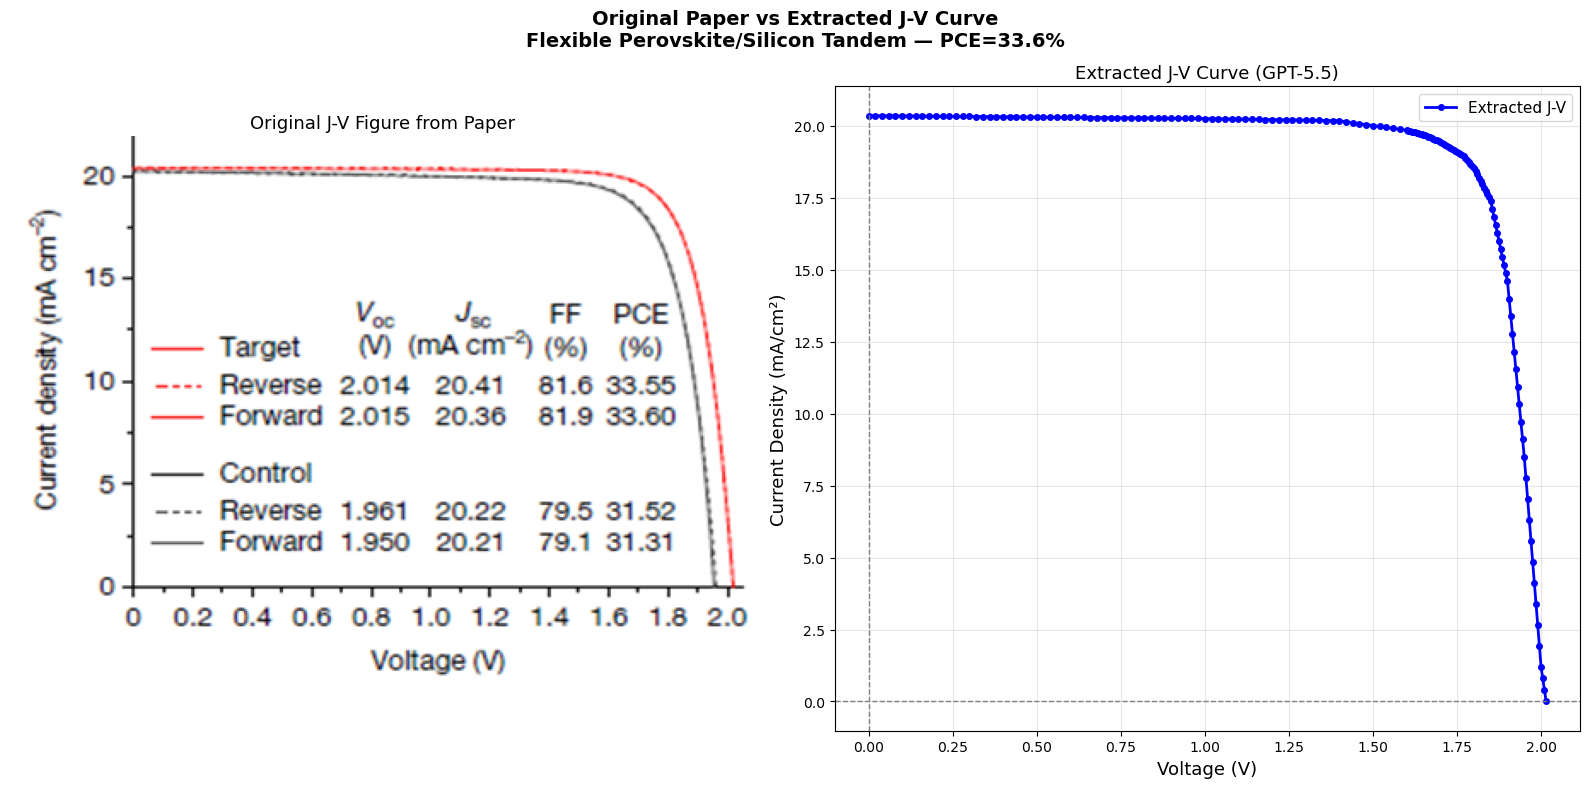

Extracted V: [0.0, 0.02, 0.04, 0.06, 0.08, 0.1, 0.12, 0.14, 0.16, 0.18, 0.2, 0.22, 0.24, 0.26, 0.28, 0.3, 0.32, 0.34, 0.36, 0.38, 0.4, 0.42, 0.44, 0.46, 0.48, 0.5, 0.52, 0.54, 0.56, 0.58, 0.6, 0.62, 0.64, 0.66, 0.68, 0.7, 0.72, 0.74, 0.76, 0.78, 0.8, 0.82, 0.84, 0.86, 0.88, 0.9, 0.92, 0.94, 0.96, 0.98, 1.0, 1.02, 1.04, 1.06, 1.08, 1.1, 1.12, 1.14, 1.16, 1.18, 1.2, 1.22, 1.24, 1.26, 1.28, 1.3, 1.32, 1.34, 1.36, 1.38, 1.4, 1.42, 1.44, 1.46, 1.48, 1.5, 1.52, 1.54, 1.56, 1.58, 1.6, 1.605, 1.61, 1.615, 1.62, 1.625, 1.63, 1.635, 1.64, 1.645, 1.65, 1.655, 1.66, 1.665, 1.67, 1.675, 1.68, 1.685, 1.69, 1.695, 1.7, 1.705, 1.71, 1.715, 1.72, 1.725, 1.73, 1.735, 1.74, 1.745, 1.75, 1.755, 1.76, 1.765, 1.77, 1.775, 1.78, 1.785, 1.79, 1.795, 1.8, 1.805, 1.81, 1.815, 1.82, 1.825, 1.83, 1.835, 1.84, 1.845, 1.85, 1.855, 1.86, 1.865, 1.87, 1.875, 1.88, 1.885, 1.89, 1.895, 1.9, 1.905, 1.91, 1.915, 1.92, 1.925, 1.93, 1.935, 1.94, 1.945, 1.95, 1.955, 1.96, 1.965, 1.97, 1.975, 1.98, 1.985, 1.99, 1.995, 2.0, 2

In [36]:
from PIL import Image
import matplotlib.pyplot as plt

V_values = [point["V"] for point in result_page2["data_points"]]
J_values = [point["J"] for point in result_page2["data_points"]]

# Create side by side comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# ── Left: Original cropped J-V figure from paper ──
original_jv = Image.open("article_image/jv.png")
axes[0].imshow(original_jv)
axes[0].set_title("Original J-V Figure from Paper", fontsize=13)
axes[0].axis("off")

# ── Right: Extracted J-V curve ──
axes[1].plot(V_values, J_values, 'b-o',
             markersize=4, linewidth=2, label="Extracted J-V")
axes[1].axhline(y=0, color='gray', linestyle='--', linewidth=1)
axes[1].axvline(x=0, color='gray', linestyle='--', linewidth=1)
axes[1].set_xlabel("Voltage (V)", fontsize=13)
axes[1].set_ylabel("Current Density (mA/cm²)", fontsize=13)
axes[1].set_title("Extracted J-V Curve (GPT-5.5)", fontsize=13)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.suptitle("Original Paper vs Extracted J-V Curve\nFlexible Perovskite/Silicon Tandem — PCE=33.6%",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Extracted V: {V_values}")
print('\n')
print(f"Extracted J: {J_values}")

In [39]:
# Calculate the parameters